Nombre y apellidos: Alfonso Íñiguez Cortés \
Correo: aic35@alu.ua.es \
Grupo: 3 

# BFS. Exploración de grafos

In [11]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown 

Implementación del algoritmo BFS:

In [2]:
def bfs_numpy(graph, source, target):
    nodes = list(graph.nodes())
    adjacency_matrix = nx.to_numpy_array(graph, nodelist=nodes)

    visited = np.zeros(len(nodes), dtype=bool)
    source_index = nodes.index(source)
    target_index = nodes.index(target)
    visited[source_index] = True

    to_explore = [source_index]
    current_position = 0  # BFS: always the first pending element

    parent = np.ones(len(nodes), dtype=int) * -1
    steps = 0

    while current_position < len(to_explore):
        steps += 1
        current_index = to_explore[current_position]
        current_position += 1

        if current_index == target_index:
            break

        neighbors = np.where(adjacency_matrix[current_index] == 1)[0]
        for neighbor_index in neighbors:
            if not visited[neighbor_index]:
                visited[neighbor_index] = True
                to_explore.append(neighbor_index)
                parent[neighbor_index] = current_index

    shortest_path = []
    if parent[target_index] != -1 or source_index == target_index:
        current = target_index
        while current != -1:
            shortest_path.insert(0, nodes[current])
            current = parent[current]

    return steps, shortest_path

## Ejercicios

### Ejercicio 1

El algoritmo BFS es un algoritmo de exploración de grafos. Este algoritmo explora el grafo por niveles: visita a un vecino, luego a los vecinos del vecino y asi sucesivamente. De esa forma, después de explorar un grafo al completo el algoritmo sabe siempre cual es el camino más corto de un nodo hasta otro, es decir, este algoritmo garantiza siempre el **camino más óptimo** (entre un _target_ (destino) y un _source_ (origen))

### Explicación algoritmo

- #### Bloque 1 - Inicialización
---

In [ ]:
nodes = list(graph.nodes())
adjacency_matrix = nx.to_numpy_array(graph, nodelist=nodes)

visited = np.zeros(len(nodes), dtype=bool)
source_index = nodes.index(source)
target_index = nodes.index(target)
visited[source_index] = True

to_explore = [source_index]
current_position = 0  

parent = np.ones(len(nodes), dtype=int) * -1
steps = 0

- **nodes** &rarr; Lista ordenada de todos los nodos del grafo. La lista es necesaria puesto que se trabaja con los índices de los nodos, no con los nombres reales de estos.

- **adjacency_matrix** &rarr; Matriz NxN donde la celda ```[i][j] = 1``` si hay una arsita entre el nodo i y el nodo j. Si no hay arista, el valor correspondiente es 0.

- **visited** &rarr; Array de valores booleanos, uno por nodo. Este array nos dice que nodo ya ha sido explorado, lo cual sirve para no explorar el mismo nodo más de una vez (podría casar bucles)

- **source_index** &rarr; Índice del nodo donde comienza la búsqueda

- **target_index** &rarr; Índice del nodo que queremos alcanzar 

- **visited[source_index]** &rarr; Marcamos como visitado el nodo desde el cual comenzamos la búsqueda

- **to_explore** &rarr; Cola pendiente del BFS, es decir, los nodos pendientes de explorar. Esta lista comienza en el nodo de origen

- **current_position** &rarr; PUntero que avanza. Apunta al siguiente nodo a explorar

- **parent** &rarr; Array que guarda, por cada nodo, desde qué nodo hemos llegado hasta a él. Este array es el que se usa para reconstruir el camino final. El array esta inicializado a -1 (todos) ya que ningún nodo tiene padre todavía

- **steps** &rarr; Contador de iteraciones del bucle principal

- #### Bucle principal
---

In [ ]:
while current_position < len(to_explore):
    steps += 1
    current_index = to_explore[current_position]
    current_position += 1

    if current_index == target_index:
        break

    neighbors = np.where(adjacency_matrix[current_index] == 1)[0]
    for neighbor_index in neighbors:
        if not visited[neighbor_index]:
            visited[neighbor_index] = True
            to_explore.append(neighbor_index)
            parent[neighbor_index] = current_index

- _while_ &rarr; El bucle continúa hasta que queden nodos por explorar. Lo que hacemos es seleccionar al nodo que apunta a **current_position** y avanzamos el puntero. Imita el comportamiento *FIFO (First In First Out)* de una cola. De esta forma se garantiza que este algoritmo explore el grafo por niveles

- **current_index** &rarr; Seleccionamos al nodo que apunta a **current_position**

- **current_position** &rarr; Avanzamos el puntero para la siguiente iteración. Esta estructura imita el comportamiento *FIFO (First In First Out)* de una cola. De esta forma se garantiza que este algoritmo explore el grafo por niveles

- **steps** &rarr; Sumamos uno por iteración

- _if_ &rarr; Si el nodo actual es igual que el nodo destino, hemos encontrado el camino más corto y el bucle finaliza. Podemos para aquí ya que BFS garantiza que el primero en llegar al destino llegó por el camino más corto

- **neighbors** &rarr; Mira la fila del nodo actual en la matriz de adyacencia y devuelve los índices donde haya un uno, es decir, donde exista una arsita, es decir, sus vecinos

- _for_ &rarr; Bucle donde se recorren los vecinos del nodo actual. Para cada vecino: si no ha sido visitado, se marca como visitado, lo añadimos a la cola con los nodos a explorar y guardamos que hemos llegado hasta el desde el nodo actual (para la reconstrucción)


- #### Bloque 3 - Reconstrucción del camino
---

In [ ]:
shortest_path = []
if parent[target_index] != -1 or source_index == target_index:
    current = target_index
    while current != -1:
        shortest_path.insert(0, nodes[current])
        current = parent[current]

return steps, shortest_path

- **shortest_path** &rarr; Lista donde se van a guardar los índices del camino más corto entre el _source_ y el _target_

- _if_ &rarr; Si el nodo final no tiene padres o el nodo inicial y el final son el mismo nodo no se puede realizar la reconstrucción

- **current** &rarr; Comenzamos la reconstrucción desde atrás, luego asignamos el nodo destino al nodo actual

- _while_ &rarr; El único nodo sin padre (valor -> -1) es el nodo origen. Este bucle recorre los nodos hasta llegar al padre (justo antes de procesarlo)

- **shortest_path.insert** &rarr; Insertamos el nodo actual al principio de la lista. Lo hacemos así puesto que recorremos el camino hacia atrás (obtendríamos el camino pero al revés)

- **current = parent[current]** &rarr; Seleccionamos el padre del nodo actual para seguir reconstruyendo el camino

## BFS paso a paso (prints)

## Grafos sintéticos

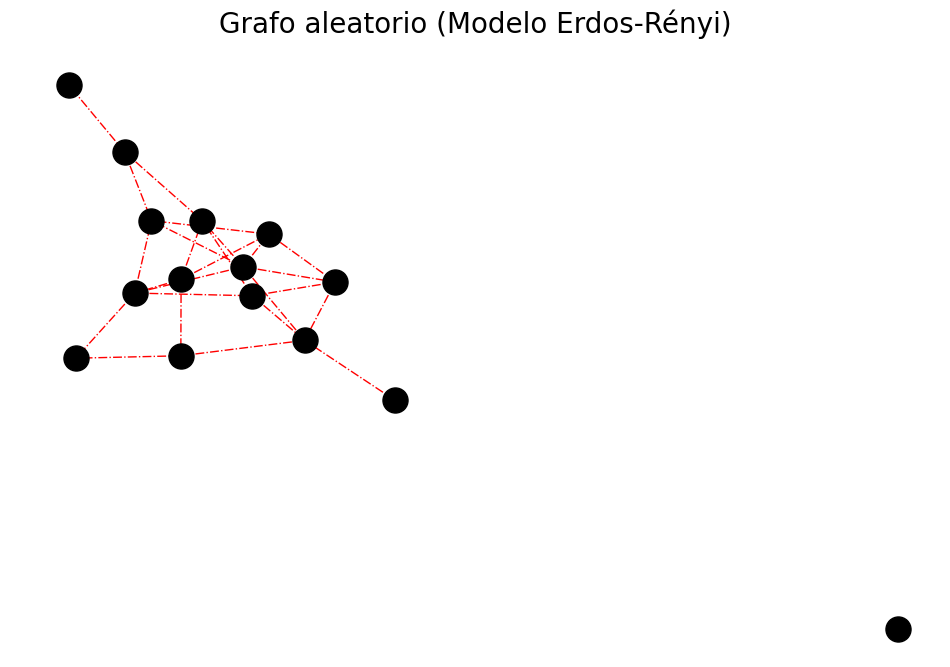

---

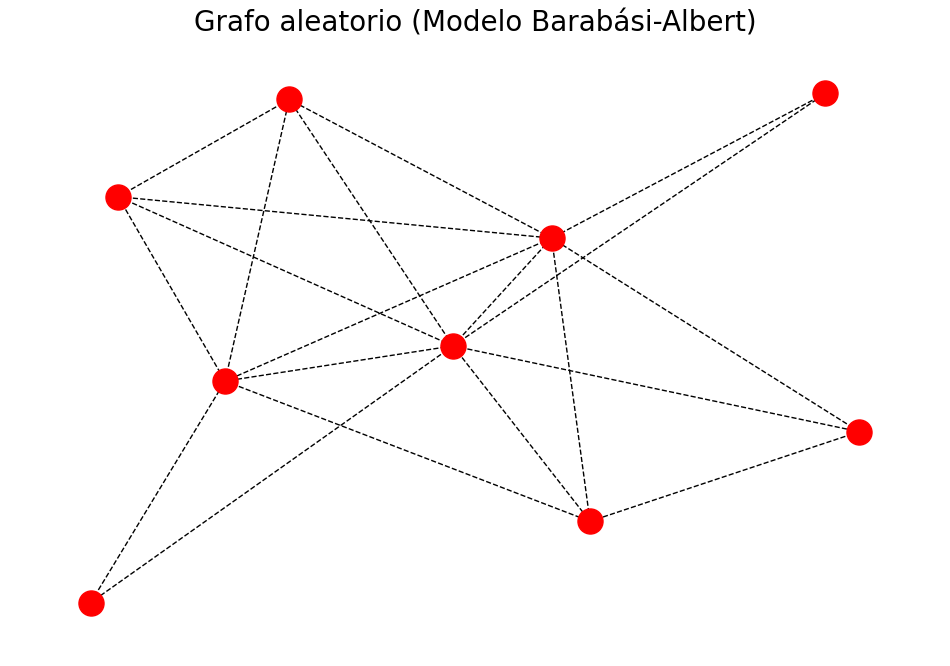

---

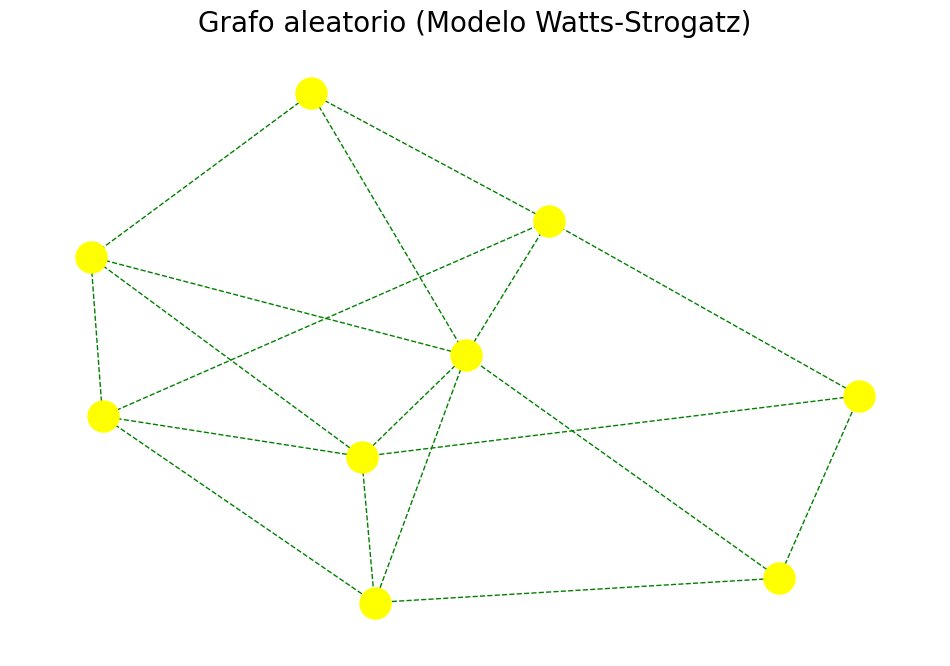

---

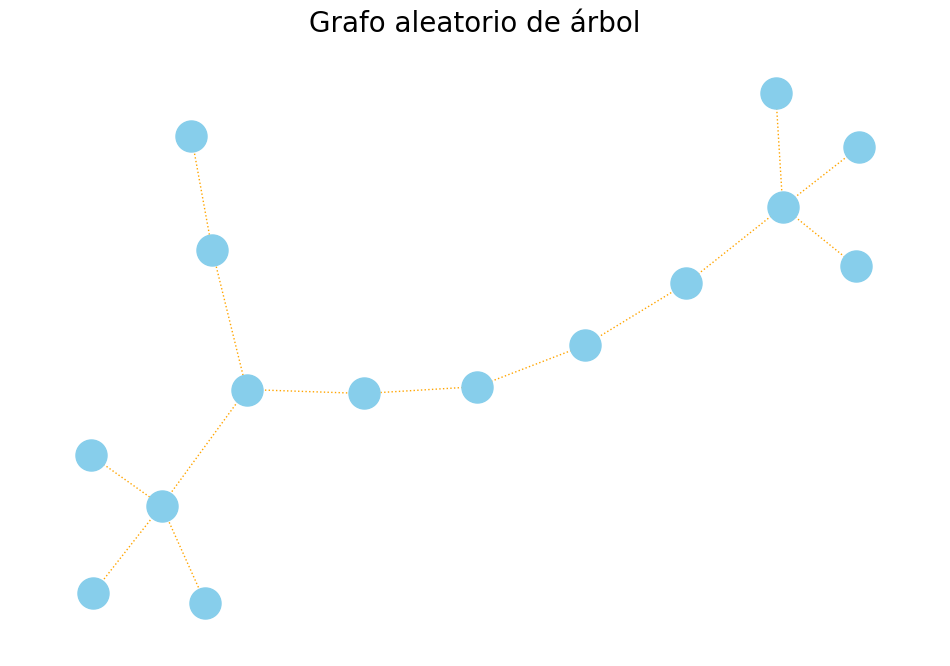

---

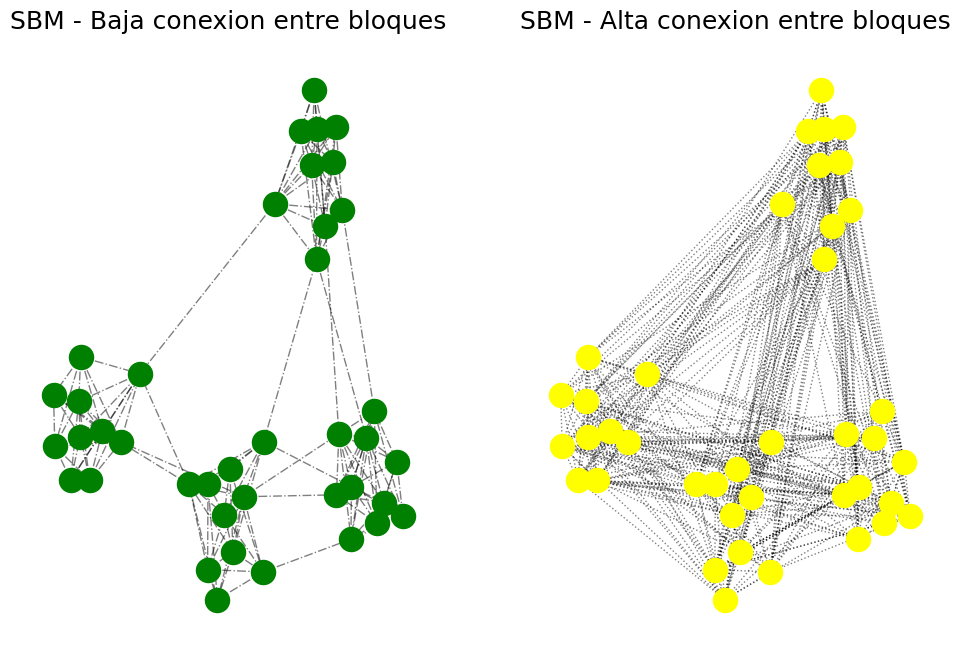

In [20]:
######################################
# ERDOS-RENYI
######################################

e_r = nx.erdos_renyi_graph(15, 0.25)   # 10 nodos | Probabilidad de arista del 50%

# Mostramos el grafo por pantalla
plt.figure(figsize=(12,8))
plt.title('Grafo aleatorio (Modelo Erdos-Rényi)', fontsize = 20)

# Vamos a calcular la posiciones (nodos)
posiciones = nx.spring_layout(e_r, seed = 18)

# Dibujamos los nodos y arsitas
nx.draw_networkx_nodes(e_r, posiciones, node_color = 'black', node_size = 325)
nx.draw_networkx_edges(e_r, posiciones, edge_color = 'red', style = '-.')

plt.axis('off')
plt.show()
display(Markdown("---"))

# --------------------------------------#

######################################
# BARABASI-ALBERT
######################################

b_a = nx.barabasi_albert_graph(9, 4, seed=10)   # 10 nodos | Nº enlaces por nodo

# Mostramos el grafo por pantalla
plt.figure(figsize=(12,8))
plt.title('Grafo aleatorio (Modelo Barabási-Albert)', fontsize = 20)

# Vamos a calcular la posiciones (nodos)
posiciones = nx.spring_layout(b_a, seed = 8)

# Dibujamos los nodos y arsitas
nx.draw_networkx_nodes(b_a, posiciones, node_color = 'red', node_size = 325)
nx.draw_networkx_edges(b_a, posiciones, edge_color = 'black', style = '--')

plt.axis('off')
plt.show()
display(Markdown("---"))

# --------------------------------------#

######################################
# WATTS-STROGATZ
######################################

w_s = nx.watts_strogatz_graph(9, 4, 0.5)   # 12 nodos | Grado medio | Probabilidad reconexión

# Mostramos el grafo por pantalla
plt.figure(figsize=(12,8))
plt.title('Grafo aleatorio (Modelo Watts-Strogatz)', fontsize = 20)

# Vamos a calcular la posiciones (nodos)
posiciones = nx.spring_layout(w_s, seed = 16)

# Dibujamos los nodos y arsitas
nx.draw_networkx_nodes(w_s, posiciones, node_color = 'yellow', node_size = 500)
nx.draw_networkx_edges(w_s, posiciones, edge_color = 'green', style = '--')

plt.axis('off')
plt.show()
display(Markdown("---"))

# --------------------------------------#

######################################
# TREE
######################################

# Usamos la función "random_tree" para generar un grafo de árbol
t = nx.random_tree(15, seed=99)   # 10 nodos

# Mostramos el grafo por pantalla
plt.figure(figsize=(12,8))
plt.title('Grafo aleatorio de árbol', fontsize = 20)

# Vamos a calcular la posiciones (nodos)
posiciones = nx.spring_layout(t, seed = 16)

# Dibujamos los nodos y arsitas
nx.draw_networkx_nodes(t, posiciones, node_color = 'skyblue', node_size = 500)
nx.draw_networkx_edges(t, posiciones, edge_color = 'orange', style = ':')

plt.axis('off')
plt.show()
display(Markdown("---"))

# --------------------------------------#

######################################
# STOCHASTIC_BLOCK_MODEL (SBM)
######################################
# Creamos 4 bloques de 10 nodos cada uno
sizes = [10, 10, 10, 10]

# Definimos las matrices de probabilidad:
    # Baja: Probabilidad baja conexión entre bloques distintos
    # Alta: Probabilidad alta conexión entre bloques distintos
baja = [
    [0.8, 0.02, 0.02, 0.02],
    [0.02, 0.8, 0.02, 0.02],
    [0.02, 0.02, 0.8, 0.02],
    [0.02, 0.02, 0.02, 0.8]
]
alta = [
    [0.8, 0.4, 0.4, 0.4],
    [0.4, 0.8, 0.4, 0.4],
    [0.4, 0.4, 0.8, 0.4],
    [0.4, 0.4, 0.4, 0.8]
]
# Definimos la semilla para que los resultados sean reproducibles
seed = 96

# Creamos los 2 grafos (SBM)
G1 = nx.stochastic_block_model(sizes, baja, seed=seed)  # El primero -> Probabilidad alta
G2 = nx.stochastic_block_model(sizes, alta, seed=seed)  # El segundo -> Probabilidad baja

# Calculamos las posiciones (las mismas para los dos grafos)
pos = nx.spring_layout(G1, seed=seed)
# Vamos a dividir los dos grafos en una misma figura
fig, axes = plt.subplots(1, 2, figsize=(12,8))

# Primer grafo
#--------------#
# Definimos título
axes[0].set_title('SBM - Baja conexion entre bloques', fontsize = 18)  
nx.draw_networkx_nodes(G1, pos, node_size=300, node_color='green', ax=axes[0])  # Dibujamos los nodos
nx.draw_networkx_edges(G1, pos, width=1.0, alpha=0.5, edge_color='black', style='-.', ax=axes[0]) # Dibujamos las aristas
axes[0].axis('off')

# Segundo grafo
#---------------#
# Definimos título
axes[1].set_title('SBM - Alta conexion entre bloques', fontsize = 18)
nx.draw_networkx_nodes(G2, pos, node_size=300, node_color= 'yellow', ax=axes[1])         # Dibujamos los nodos
nx.draw_networkx_edges(G2, pos, width=1.0, alpha=0.5, style=':', ax=axes[1])  # Dibujamos las arsitas
axes[1].axis('off')

# Mostramos el resultado por pantalla
plt.show()

## Probamos BFS en los grafos

### Ejercicio 2

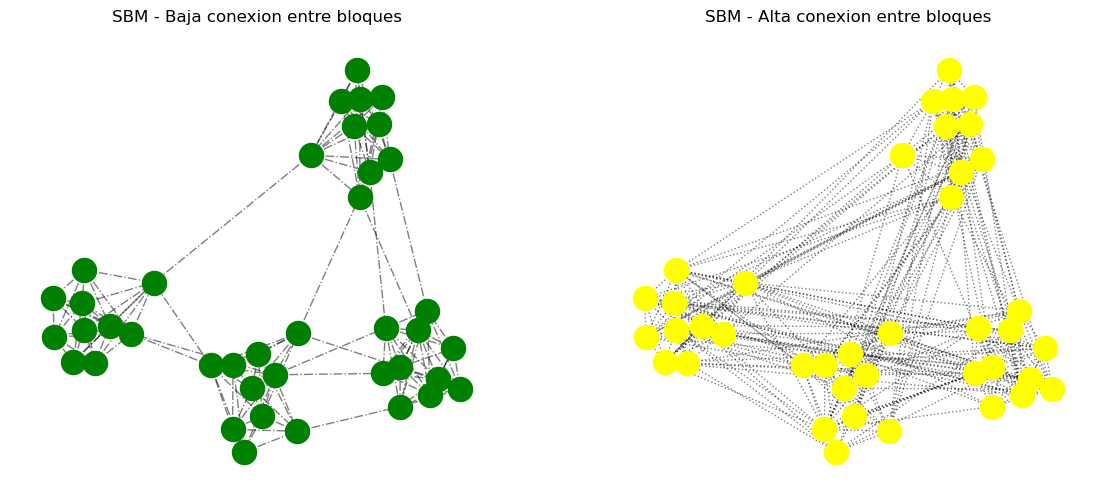

In [8]:
# Creamos 4 bloques de 10 nodos cada uno
sizes = [10, 10, 10, 10]

# Definimos las matrices de probabilidad:
    # Baja: Probabilidad baja conexión entre bloques distintos
    # Alta: Probabilidad alta conexión entre bloques distintos
baja = [
    [0.8, 0.02, 0.02, 0.02],
    [0.02, 0.8, 0.02, 0.02],
    [0.02, 0.02, 0.8, 0.02],
    [0.02, 0.02, 0.02, 0.8]
]

alta = [
    [0.8, 0.2, 0.2, 0.2],
    [0.2, 0.8, 0.2, 0.2],
    [0.2, 0.2, 0.8, 0.2],
    [0.2, 0.2, 0.2, 0.8]
]

# Definimos la semilla para que los resultados sean reproducibles
seed = 96

# Creamos los 2 grafos (SBM)
G1 = nx.stochastic_block_model(sizes, baja, seed=seed)  # El primero -> Probabilidad alta
G2 = nx.stochastic_block_model(sizes, alta, seed=seed)  # El segundo -> Probabilidad baja

# Calculamos las posiciones (las mismas para los dos grafos)
pos = nx.spring_layout(G1, seed=seed)
# Vamos a dividir los dos grafos en una misma figura
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Primer grafo
#--------------#
# Definimos título
axes[0].set_title('SBM - Baja conexion entre bloques')  
nx.draw_networkx_nodes(G1, pos, node_size=300, node_color='green', ax=axes[0])  # Dibujamos los nodos
nx.draw_networkx_edges(G1, pos, width=1.0, alpha=0.5, edge_color='black', style='-.', ax=axes[0]) # Dibujamos las aristas
axes[0].axis('off')

# Segundo grafo
#---------------#
# Definimos título
axes[1].set_title('SBM - Alta conexion entre bloques')
nx.draw_networkx_nodes(G2, pos, node_size=300, node_color= 'yellow', ax=axes[1])         # Dibujamos los nodos
nx.draw_networkx_edges(G2, pos, width=1.0, alpha=0.5, style=':', ax=axes[1])  # Dibujamos las arsitas
axes[1].axis('off')

# Mostramos el resultado por pantalla
plt.show()

**Aplicamos el algoritmo a cada grafo sintético**

Érdos

#### Resultados obtenidos y conclusión

Hemos aplicado el algoritmo BFS a los dos grafos SBM generados en la práctica anterior.
En G1 (baja conexión entre bloques) el camino encontrado es más largo, mientras que en G2
(alta conexión entre bloques) el camino es notablemente más corto.

**¿Cómo se comporta el algoritmo en estos grafos?** \
&rarr; El algoritmo funciona correctamente en ambos grafos, encontrando siempre el camino
más corto entre el nodo origen y el nodo destino. En G2, al haber muchas más conexiones,
el algoritmo encuentra el destino rápidamente ya que tiene muchos caminos disponibles entre
bloques. En G1, el algoritmo tiene que explorar más nodos antes de encontrar el destino,
ya que las conexiones entre bloques son escasas y los caminos alternativos son pocos.

**¿Por qué en algunos casos se necesitan más pasos para encontrar el camino más corto?** \
&rarr; En G1, la baja probabilidad de conexión entre bloques hace que haya muy pocos puentes
entre comunidades. Esto obliga al algoritmo a explorar más nodos dentro de cada bloque antes
de encontrar una arista que le permita saltar al siguiente. En G2, en cambio, como cualquier
nodo puede conectarse con cualquier otro independientemente del bloque, el algoritmo encuentra
un camino directo entre origen y destino en muy pocos pasos.

# Por si acaso?

In [8]:
def bfs_numpy(graph, source, target):

    display(Markdown('## Recorriendo el algoritmo con BFS'))
    display(Markdown('---'))

    # Listamos los nodos del grafo a explorar
    nodes = list(graph.nodes())
    display(Markdown('#### Datos iniciales'))
    display(Markdown(f'**Lista de nodos del grafo:** {nodes}'))

    # Obtenemos la matriz de adyacencia del grafo
    adjacency_matrix = nx.to_numpy_array(graph, nodelist=nodes)
    display(Markdown(f'**Matriz de adyacencia:**'))
    print(adjacency_matrix)

    # Array (booleano) para guardar los nodos ya visitados
    visited = np.zeros(len(nodes), dtype=bool)

    # Posición del nodo origen (dentro de la lista 'nodes')
    source_index = nodes.index(source)

    # Posición del nodo destino (dentro de la lista 'nodes')
    target_index = nodes.index(target)

    display(Markdown(f'**Nodo origen:** {source} (índice {source_index}) | **Nodo destino:** {target} (índice {target_index})'))

    # El nodo desde donde partimos marcado como visitado
    visited[source_index] = True

    # Lista de nodos pendientes de explorar, empezamos con el origen
    to_explore = [source_index]

    # Puntero que indica qué nodo de la lista estamos explorando ahora
    current_position = 0

    # Array para guardar de qué nodo venimos, usado para la reconstrucción del camino
    parent = np.ones(len(nodes), dtype=int) * -1

    # Número de pasos
    steps = 0

    display(Markdown('---'))
    display(Markdown(f'#### Comenzando exploración desde el nodo {source}...'))

    while current_position < len(to_explore):
        steps += 1
        current_index = to_explore[current_position]
        current_position += 1

        display(Markdown('---'))
        display(Markdown(f'**Paso {steps}** | Nodo actual: `{nodes[current_index]}`'))

        if current_index == target_index:
            display(Markdown(f'**Destino encontrado: {target}**'))
            break

        # Vecinos del nodo actual
        neighbors = np.where(adjacency_matrix[current_index] == 1)[0]
        display(Markdown(f'Vecinos de `{nodes[current_index]}`: {[nodes[i] for i in neighbors]}'))

        # Recorremos los vecinos del nodo actual
        for neighbor_index in neighbors:
            if not visited[neighbor_index]:
                visited[neighbor_index] = True
                to_explore.append(neighbor_index)
                parent[neighbor_index] = current_index
                display(Markdown(f'Añadimos a la lista: `{nodes[neighbor_index]}`'))

        display(Markdown(f'*Pasando al siguiente paso...*'))

    shortest_path = []
    if parent[target_index] != -1 or source_index == target_index:
        current = target_index
        while current != -1:
            shortest_path.insert(0, nodes[current])
            current = parent[current]

    display(Markdown('---'))
    display(Markdown('#### Resultado'))
    display(Markdown(f'**Camino óptimo:** {shortest_path}'))
    display(Markdown(f'**Número de pasos:** {steps}'))

    return steps, shortest_path